In [1]:
import cafe

cafe.logger.setLevel("DEBUG")
cafe.settings.backend = "dynverse_docker"

INFO                                                                                                                                                                                                    
           ██████╗ █████╗ ███████╗███████╗                                                                                                                                                              
          ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                              
          ██║     ███████║█████╗  █████╗                                                                                                                                                                
          ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                            

In [2]:
fadata = cafe.data.read_pancrease()
fadata

DEBUG    |- Reading data from '/root/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad'...                                                                                                         
DEBUG    |- transfer 'X' and 'Spliced' matrix from csr to csc for better dynverse docker performance                                                                                                    
DEBUG    |- Create a FateAnnData object from an existing AnnData object.                                                                                                                                
DEBUG    |- recognizing prior information...                                                                                                                                                            
DEBUG    |--- recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                               

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cafe', 'filename'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

In [3]:
import scvelo as scv

scv.pp.filter_and_normalize(fadata, n_top_genes=2000) # need optimized

Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.


In [6]:
method2parameters = {
    # "ti_paga": {},
    # "ti_slingshot": {},
    "ti_tscan": {},
}

for method_name, parameters in method2parameters.items():
    parameters["repreprocess"] = False # use common preprocessing
    parameters["benchmark_resource"] = True # record resource usage
    method = cafe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata, parameters=parameters)
    # save in time, without waiting for all methods to finish, waypoint are not calculated
    fadata.write_trajectory_dict(model_name_list=[fadata.model_name])

DEBUG    |- Docker image(dynverse/ti_tscan:v0.9.9.01) loaded, entry point is '['/code/run.R']'                                                                                                          
INFO     |- method backend loaded: Dynverse Docker Backend: docker image 'dynverse/ti_tscan:v0.9.9.01'                                                                                                  
DEBUG    |- set new log file: .cafe/pancreas/log/20251201_094828__ti_tscan-dynverse_docker__unWkKEQxJh.log                                                                                              
DEBUG    |- continue logging from old file: /root/PyCode/scRNA/CellFateExplorer/Cafe/notebook_dev/hzy/.cafe/cafe_debug.log                                                                              
DEBUG    |- definition input_df:           input_id  required        type                                                                                                                           

DEBUG    |- extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                                                 
DEBUG    |- calculate new trajectory embedding for model_name:ref, basis:X_umap.                                                                                                                        
DEBUG    |- add waypoints                                                                                                                                                                               
DEBUG    |- FateAnnData add_waypoints                                                                                                                                                                   
DEBUG    |- add waypoints shape is (212, 3696) for 'ref', finished!                                                                                                                                 

array([[<Axes: title={'center': 'ref(clusters)'}, xlabel='X_umap1', ylabel='X_umap2'>,
        <Axes: title={'center': 'ti_tscan-dynverse_docker(clusters)'}, xlabel='X_umap1', ylabel='X_umap2'>],
       [<Axes: title={'center': 'ref(milestone)'}, xlabel='X_umap1', ylabel='X_umap2'>,
        <Axes: title={'center': 'ti_tscan-dynverse_docker(milestone)'}, xlabel='X_umap1', ylabel='X_umap2'>]],
      dtype=object)

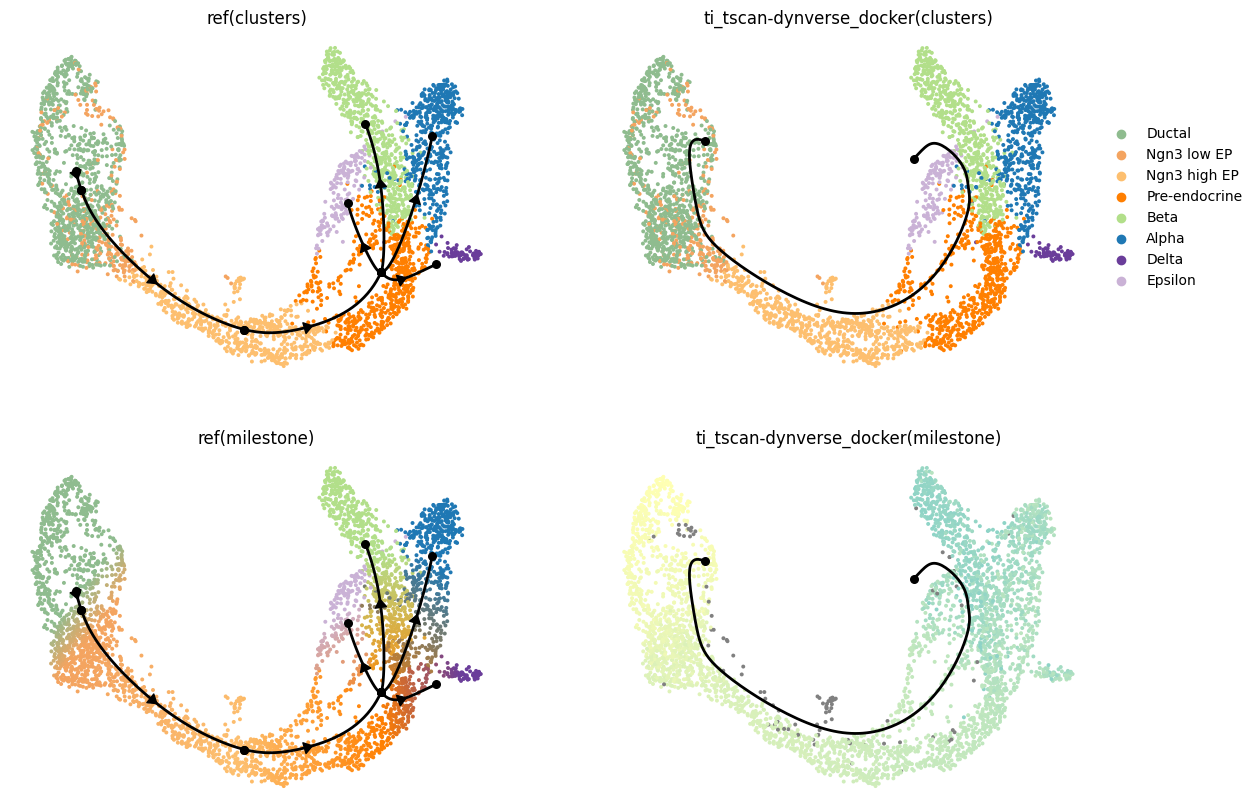

In [7]:
model_name_list = fadata.get_all_model_name(parse=False)
color_list = ["clusters", "milestone"]

cafe.plot.plot_trajectory(fadata, model_name=model_name_list, color=color_list)

In [8]:
fadata.write_trajectory_dict() 

DEBUG    |- write trajectory 'ref' to '.cafe/pancreas/trajectory_history/ref.pkl'                                                                                                                       
DEBUG    |- write trajectory '20251201_094828__ti_tscan-dynverse_docker__unWkKEQxJh' to '.cafe/pancreas/trajectory_history/20251201_094828__ti_tscan-dynverse_docker__unWkKEQxJh.pkl'                   
